In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [6]:
df= pd.read_csv('HouseTS.csv')

In [7]:
df.head()

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,...,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Alpharetta
1,2012-04-30,61870.0,245000.0,40.723982,130.528256,22.0,29.0,56.0,69.0,89.5,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202421.064584,Atlanta-Sandy Springs-Alpharetta
2,2012-05-31,125500.0,217450.0,63.913043,119.919216,24.0,40.0,63.0,60.0,144.5,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202681.309539,Atlanta-Sandy Springs-Alpharetta
3,2012-06-30,153000.0,189900.0,81.598080,105.617353,34.0,46.0,50.0,57.0,126.0,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202998.603897,Atlanta-Sandy Springs-Alpharetta
4,2012-07-31,165500.0,154000.0,81.598080,83.921175,39.0,49.0,42.0,50.0,80.0,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,203781.903446,Atlanta-Sandy Springs-Alpharetta


In [8]:
df_model = df.copy()

In [9]:
df.shape

(884092, 39)

In [10]:
df.columns

Index(['date', 'median_sale_price', 'median_list_price', 'median_ppsf',
       'median_list_ppsf', 'homes_sold', 'pending_sales', 'new_listings',
       'inventory', 'median_dom', 'avg_sale_to_list', 'sold_above_list',
       'off_market_in_two_weeks', 'city', 'zipcode', 'year', 'bank', 'bus',
       'hospital', 'mall', 'park', 'restaurant', 'school', 'station',
       'supermarket', 'Total Population', 'Median Age', 'Per Capita Income',
       'Total Families Below Poverty', 'Total Housing Units', 'Median Rent',
       'Median Home Value', 'Total Labor Force', 'Unemployed Population',
       'Total School Age Population', 'Total School Enrollment',
       'Median Commute Time', 'price', 'city_full'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884092 entries, 0 to 884091
Data columns (total 39 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   date                          884092 non-null  object 
 1   median_sale_price             884092 non-null  float64
 2   median_list_price             884092 non-null  float64
 3   median_ppsf                   884092 non-null  float64
 4   median_list_ppsf              884092 non-null  float64
 5   homes_sold                    884092 non-null  float64
 6   pending_sales                 884092 non-null  float64
 7   new_listings                  884092 non-null  float64
 8   inventory                     884092 non-null  float64
 9   median_dom                    884092 non-null  float64
 10  avg_sale_to_list              884092 non-null  float64
 11  sold_above_list               884092 non-null  float64
 12  off_market_in_two_weeks       884092 non-nul

In [12]:
df.describe()

,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,...,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price
count,8.840920e+05,8.840920e+05,884092.000000,884092.000000,884092.000000,884092.000000,884092.000000,884092.000000,884092.000000,884092.000000,...,884092.000000,884092.000000,884092.000000,8.840920e+05,884092.000000,884092.000000,884092.000000,884092.000000,884092.000000,8.840920e+05
mean,3.941026e+05,4.229849e+05,223.068328,231.169836,76.722786,81.471457,92.910352,77.300772,61.289875,0.978253,...,21457.525088,8714.480844,1146.686284,3.147922e+05,11455.779512,829.769133,20998.337745,20998.337745,9687.919963,3.913289e+05
std,3.815481e+05,1.899201e+06,696.724208,290.120210,76.698331,85.327617,92.695852,89.041772,82.220497,0.063550,...,19554.169658,7588.635086,547.236746,2.672194e+05,10429.516147,954.753745,19008.391216,19008.391216,8841.743137,3.445383e+05
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.046432e+04
25%,1.850000e+05,1.990000e+05,110.639667,116.818175,19.000000,17.000000,24.000000,20.000000,26.000000,0.965158,...,4404.000000,1930.000000,852.000000,1.436000e+05,2320.000000,127.000000,4369.000000,4369.000000,1945.000000,1.897063e+05
50%,3.025000e+05,3.200000e+05,166.093929,173.142587,55.000000,57.000000,67.000000,50.000000,45.000000,0.982062,...,17489.000000,7426.000000,1114.000000,2.501000e+05,9299.000000,538.000000,17247.000000,17247.000000,7830.500000,3.050190e+05
75%,4.800000e+05,4.999000e+05,260.626280,270.181473,111.000000,119.000000,133.000000,103.000000,74.000000,0.998206,...,32991.000000,13564.000000,1446.000000,4.125000e+05,17702.000000,1192.000000,32290.000000,32290.000000,15013.000000,4.797111e+05
max,2.050000e+07,1.000000e+09,366700.000000,143015.398551,955.000000,1374.000000,1112.000000,1941.000000,7777.000000,1.906250,...,130605.000000,48734.000000,3501.000000,2.000001e+06,68735.000000,9735.000000,126948.000000,126948.000000,60956.000000,8.463116e+06


In [13]:
df.isnull().sum()

date                            0
median_sale_price               0
median_list_price               0
median_ppsf                     0
median_list_ppsf                0
homes_sold                      0
pending_sales                   0
new_listings                    0
inventory                       0
median_dom                      0
avg_sale_to_list                0
sold_above_list                 0
off_market_in_two_weeks         0
city                            0
zipcode                         0
year                            0
bank                            0
bus                             0
hospital                        0
mall                            0
park                            0
restaurant                      0
school                          0
station                         0
supermarket                     0
Total Population                0
Median Age                      0
Per Capita Income               0
Total Families Below Poverty    0
Total Housing 

In [14]:
df.duplicated().sum()

np.int64(0)

price                           1.000000
median_sale_price               0.918048
Median Home Value               0.833523
Per Capita Income               0.597107
median_list_ppsf                0.585900
Median Rent                     0.512043
bank                            0.359006
supermarket                     0.358915
restaurant                      0.346385
park                            0.303191
station                         0.257288
year                            0.246620
bus                             0.234104
median_ppsf                     0.233372
school                          0.217337
median_list_price               0.204623
mall                            0.202014
hospital                        0.187214
sold_above_list                 0.158118
avg_sale_to_list                0.141453
off_market_in_two_weeks         0.081181
zipcode                         0.067766
Median Age                      0.067217
Total Labor Force               0.054458
Total Housing Un

C:\Users\Compu City\AppData\Local\Temp\ipykernel_3732\882946531.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette="viridis")


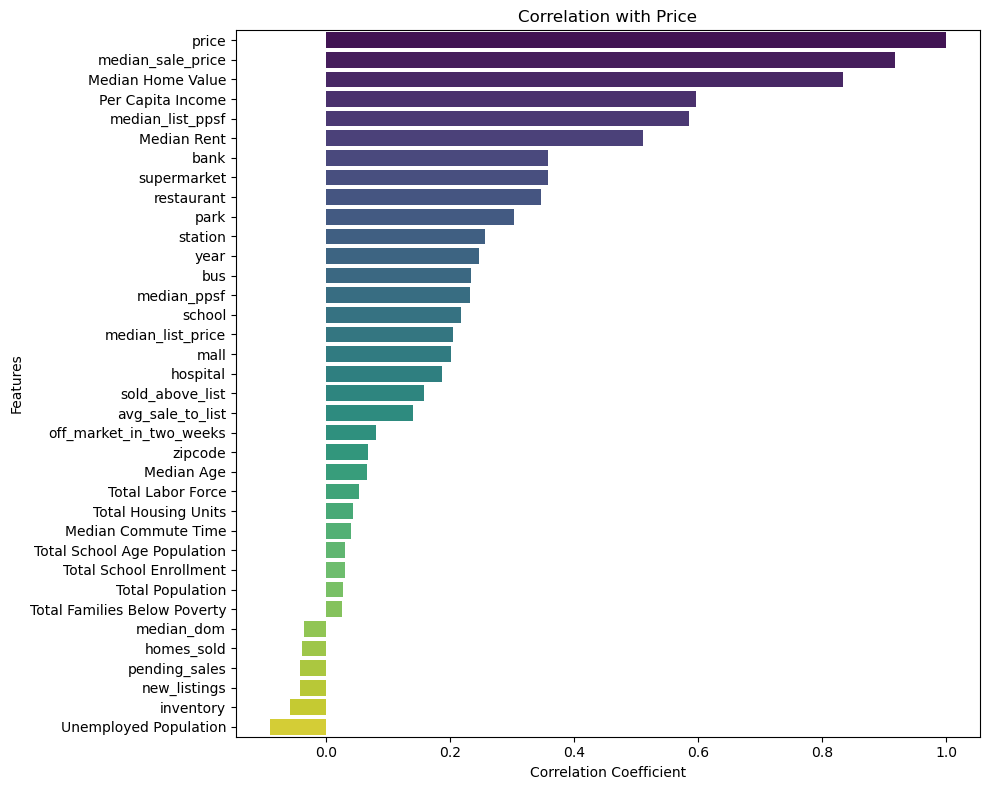

In [31]:
correlations = df.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(correlations)
plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette="viridis")
plt.title('Correlation with Price')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


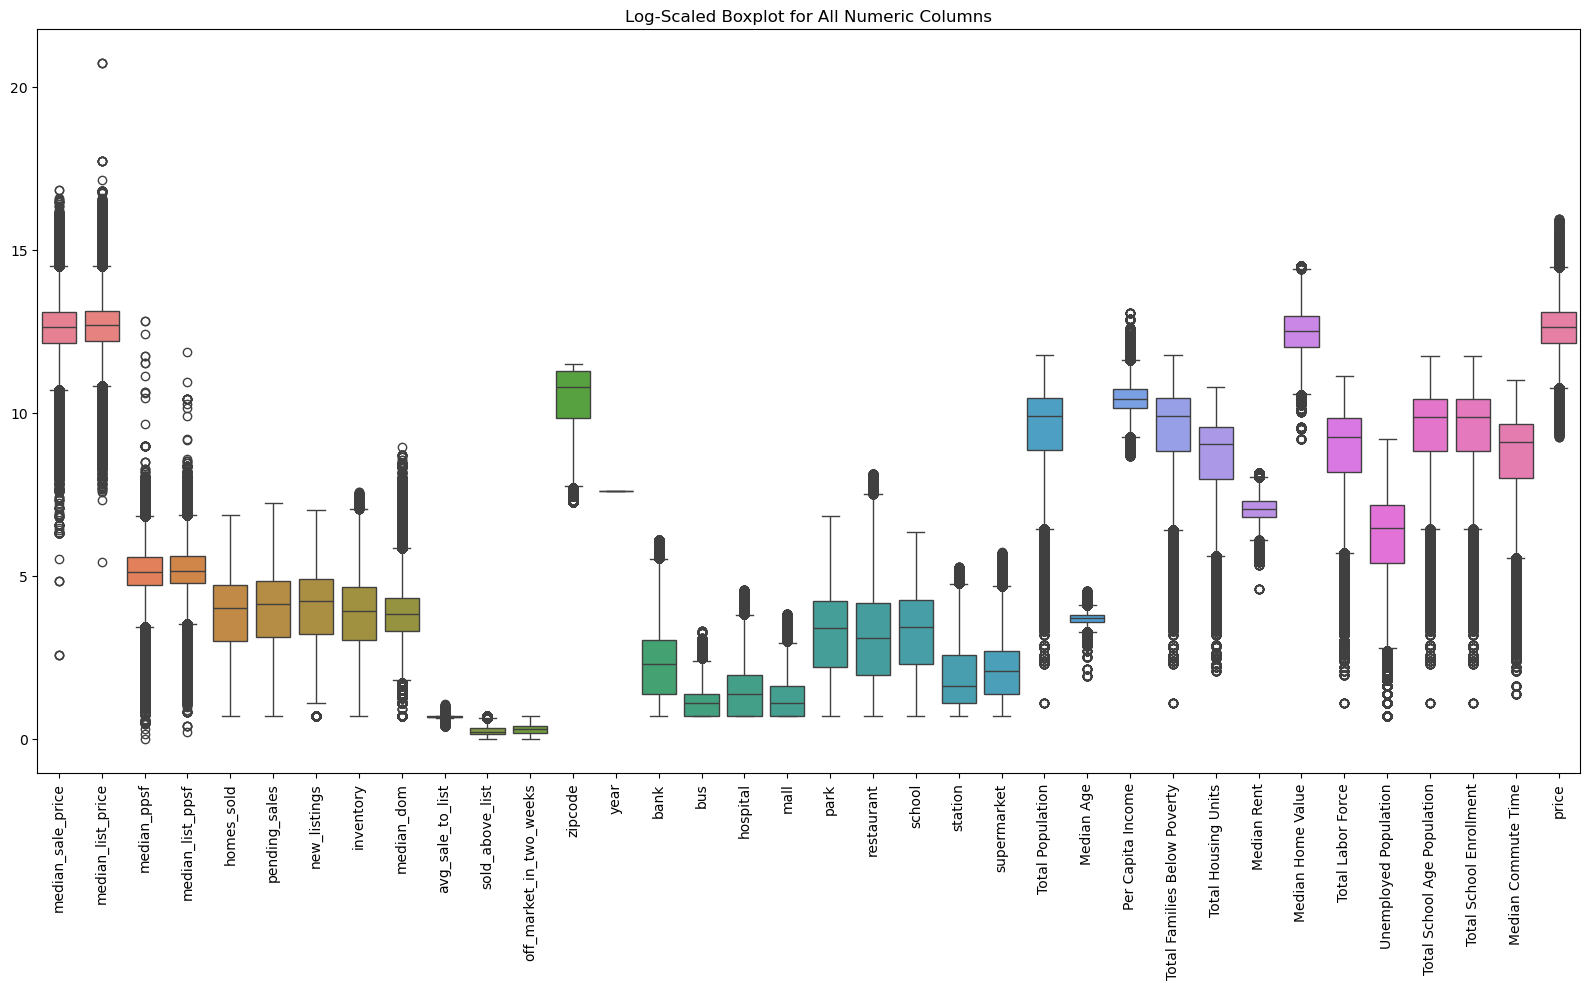

In [16]:
import numpy as np
df_box = df_model.select_dtypes(include='number').copy()
df_box = df_box[df_box > 0]  
plt.figure(figsize=(16, 10))
sns.boxplot(data=np.log1p(df_box), orient='v')  
plt.xticks(rotation=90)
plt.title("Log-Scaled Boxplot for All Numeric Columns")
plt.tight_layout()
plt.show()

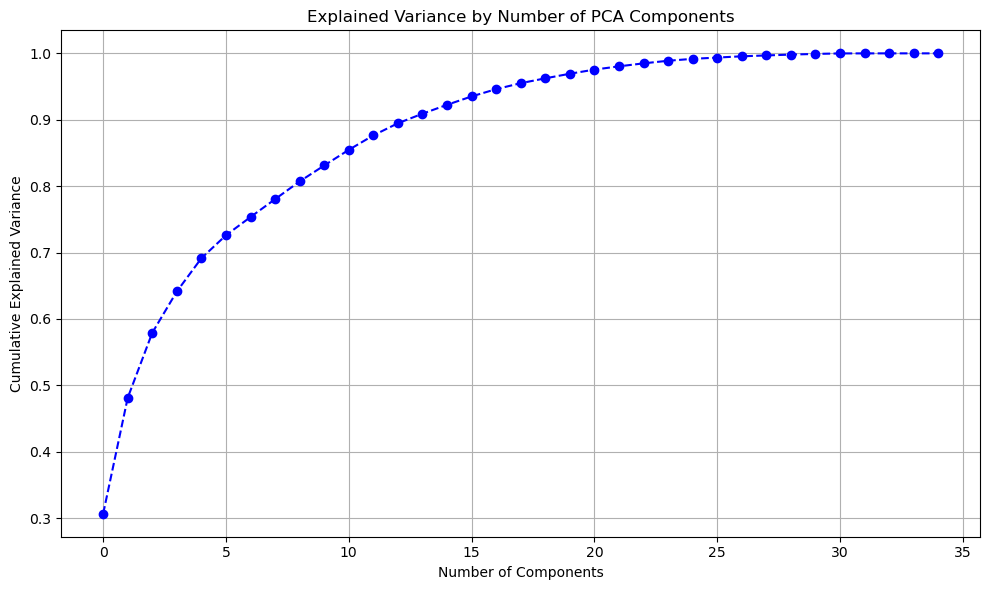

In [32]:
df_model = df_model.select_dtypes(include='number')
# Separate target and features
X = df_model.drop('price', axis=1)
y = df_model['price']
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of PCA Components')
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
X = df_model.drop('price', axis=1)
y = df_model['price']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=X.shape[1])
pca.fit(X_scaled)
loadings = np.abs(pca.components_).sum(axis=0)
feature_importance = pd.Series(loadings, index=X.columns).sort_values()
least_important = feature_importance.head(10)
print("Least contributing features:\n", least_important)
df_model = df_model.drop(columns=least_important.index.tolist())

Least contributing features:
 median_list_price               2.653111
median_ppsf                     2.719534
Total Population                2.739633
Total Families Below Poverty    2.773698
mall                            2.850314
Total Labor Force               2.911401
new_listings                    2.923765
Total Housing Units             2.925209
bus                             3.132724
Total School Age Population     3.143381
dtype: float64


In [39]:
df.head()

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,...,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Alpharetta
1,2012-04-30,61870.0,245000.0,40.723982,130.528256,22.0,29.0,56.0,69.0,89.5,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202421.064584,Atlanta-Sandy Springs-Alpharetta
2,2012-05-31,125500.0,217450.0,63.913043,119.919216,24.0,40.0,63.0,60.0,144.5,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202681.309539,Atlanta-Sandy Springs-Alpharetta
3,2012-06-30,153000.0,189900.0,81.598080,105.617353,34.0,46.0,50.0,57.0,126.0,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202998.603897,Atlanta-Sandy Springs-Alpharetta
4,2012-07-31,165500.0,154000.0,81.598080,83.921175,39.0,49.0,42.0,50.0,80.0,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,203781.903446,Atlanta-Sandy Springs-Alpharetta


In [34]:
df.drop(['city', 'city_full', 'date'], axis=1, inplace=True, errors='ignore')

In [35]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

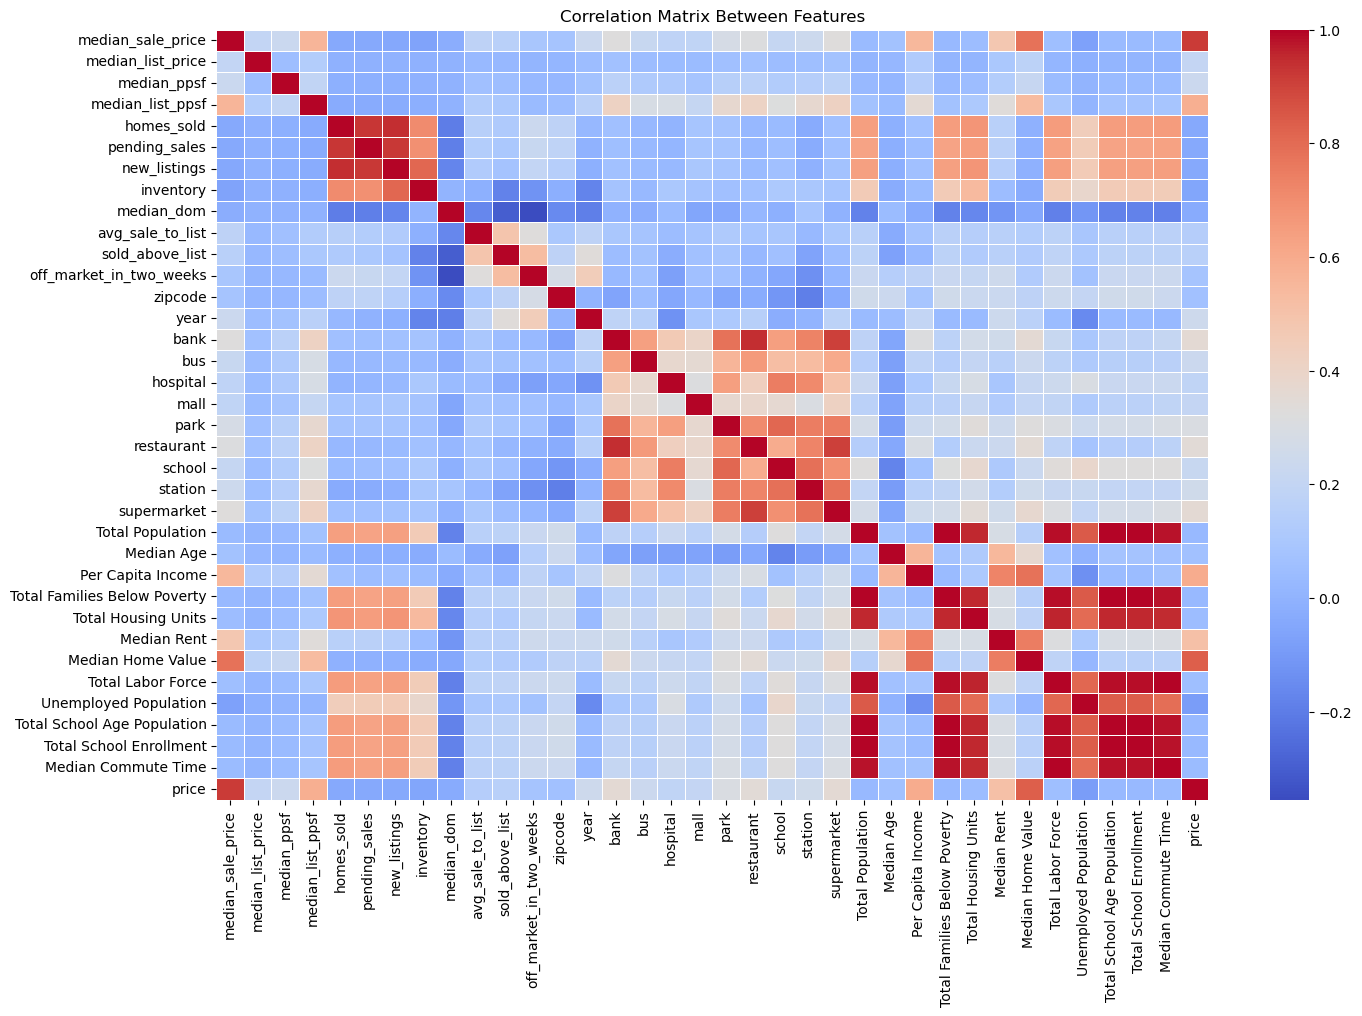

In [21]:
df_model = df.copy()  
corr_matrix = df_model.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Correlation Matrix Between Features")
plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X = df_model.drop('price', axis=1)
y = df_model['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f" Training Set: {X_train.shape[0]} rows ({(X_train.shape[0]/X.shape[0])*100:.2f}%)")
print(f" Test Set: {X_test.shape[0]} rows ({(X_test.shape[0]/X.shape[0])*100:.2f}%)")

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f" MAE: {mae:,.2f}")
print(f" RMSE: {rmse:,.2f}")
print(f" Model Accuracy (R² Score): {r2:.4f}")

 Training Set: 707273 rows (80.00%)
 Test Set: 176819 rows (20.00%)
 MAE: 47,055.03
 RMSE: 114,222.95
 Model Accuracy (R² Score): 0.8917


IQR removed 723872 rows out of 884092

Model Evaluation (IQR Only):
R² Score: 0.9170
MAE: 21,030.55
MSE: 929,430,533.02
RMSE: 30,486.56


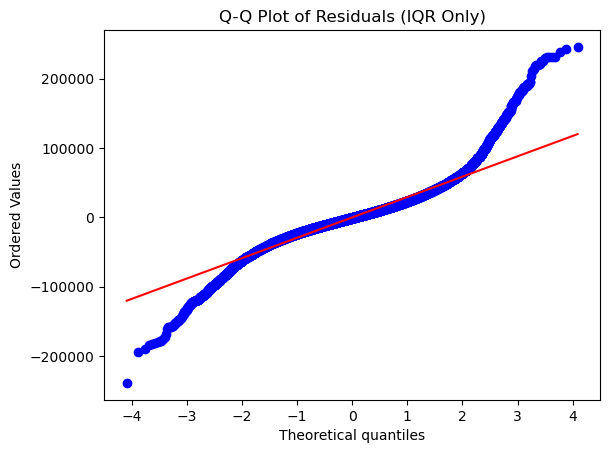

In [37]:
import pylab
import scipy.stats as stats
df_iqr = df.copy()
numeric_cols = df_iqr.select_dtypes(include='number').columns
rows_before = df_iqr.shape[0]

for col in numeric_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_iqr = df_iqr[(df_iqr[col] >= lower_bound) & (df_iqr[col] <= upper_bound)]

rows_after = df_iqr.shape[0]
print(f"IQR removed {rows_before - rows_after} rows out of {rows_before}")

X = df_iqr.drop(columns=['price'])
y = df_iqr['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nModel Evaluation (IQR Only):")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")

residuals = y_test - y_pred
stats.probplot(residuals, dist="norm", plot=pylab)
pylab.title("Q-Q Plot of Residuals (IQR Only)")
pylab.show()

In [42]:
import pylab
import scipy.stats as stats
df_before = df.copy()
df_iqr = df.copy()
iso = IsolationForest(contamination=0.01, random_state=42)
X_numeric = df_iqr.select_dtypes(include='number')
outliers = iso.fit_predict(X_numeric)
df_cleaned = df_iqr.copy()
df_cleaned['outlier'] = outliers
df_cleaned = df_cleaned[df_cleaned['outlier'] == 1].drop('outlier', axis=1)
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# . Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(" Model Evaluation After Cleaning & Scaling:")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")

 Model Evaluation After Cleaning & Scaling:
R² Score: 0.9111
MAE: 44,532.36
MSE: 9,651,224,700.56
RMSE: 98,240.65


🔍 R2 Score: 0.9131
📉 MAE: 21163.72
📉 MSE: 951238695.08
📉 RMSE: 30842.16


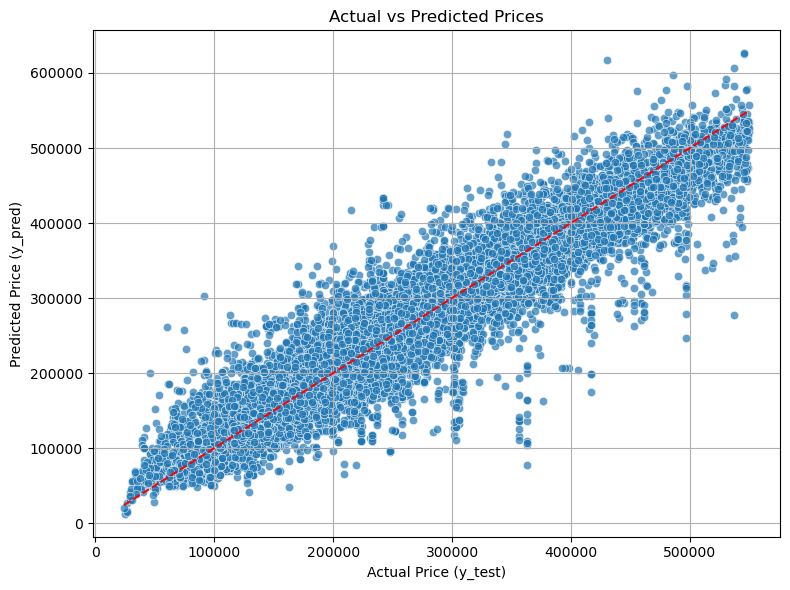

In [44]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# نسخة من الداتا الأصلية
df_before = df.copy()

# إزالة القيم المتطرفة باستخدام IQR
df_iqr = df.copy()
numeric_cols = df_iqr.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_iqr = df_iqr[(df_iqr[col] >= lower_bound) & (df_iqr[col] <= upper_bound)]

# إزالة القيم الشاذة باستخدام Isolation Forest
iso = IsolationForest(contamination=0.02, random_state=42)
X_numeric = df_iqr.select_dtypes(include='number')
outliers = iso.fit_predict(X_numeric)

df_cleaned = df_iqr.copy()
df_cleaned['outlier'] = outliers
df_cleaned = df_cleaned[df_cleaned['outlier'] == 1].drop('outlier', axis=1)

# تقسيم البيانات
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# التقييم
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# عرض النتائج
print(f"🔍 R2 Score: {r2:.4f}")
print(f"📉 MAE: {mae:.2f}")
print(f"📉 MSE: {mse:.2f}")
print(f"📉 RMSE: {rmse:.2f}")

# رسم y مقابل y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Price (y_test)")
plt.ylabel("Predicted Price (y_pred)")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
def evaluate_model(X, y, label=''):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f" Evaluation {label}")
    print("R² Score:", round(r2_score(y_test, y_pred), 4))
    print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
    print("MSE:", round(mean_squared_error(y_test, y_pred), 2))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
# ----------- Evaluation Before Cleaning -----------
df_before = df.copy()
X_before = df_before.drop(columns=['price'])
y_before = df_before['price']
evaluate_model(X_before, y_before, label="Before Cleaning")
# ----------- Evaluation After Cleaning (IQR + Isolation Forest) -----------
X_after = df_cleaned.drop(columns=['price'])
y_after = df_cleaned['price']
evaluate_model(X_after, y_after, label="After Cleaning")

 Evaluation Before Cleaning
R² Score: 0.8927
MAE: 46671.28
MSE: 12918754598.62
RMSE: 113660.7
 Evaluation After Cleaning
R² Score: 0.9013
MAE: 43935.95
MSE: 10188659871.72
RMSE: 100938.89


 Model Evaluation (Linear Regression After Cleaning):
R² Score: 0.9013
RMSE: 100,938.89
MAE: 43,935.95
MSE: 10,188,659,871.72


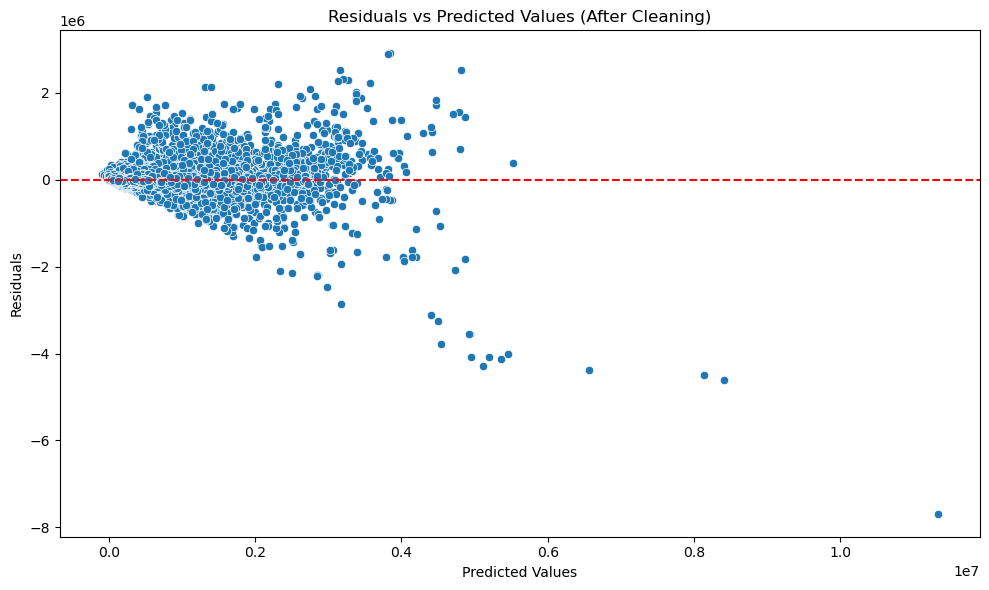

In [40]:
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(" Model Evaluation (Linear Regression After Cleaning):")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values (After Cleaning)')
plt.tight_layout()
plt.show()

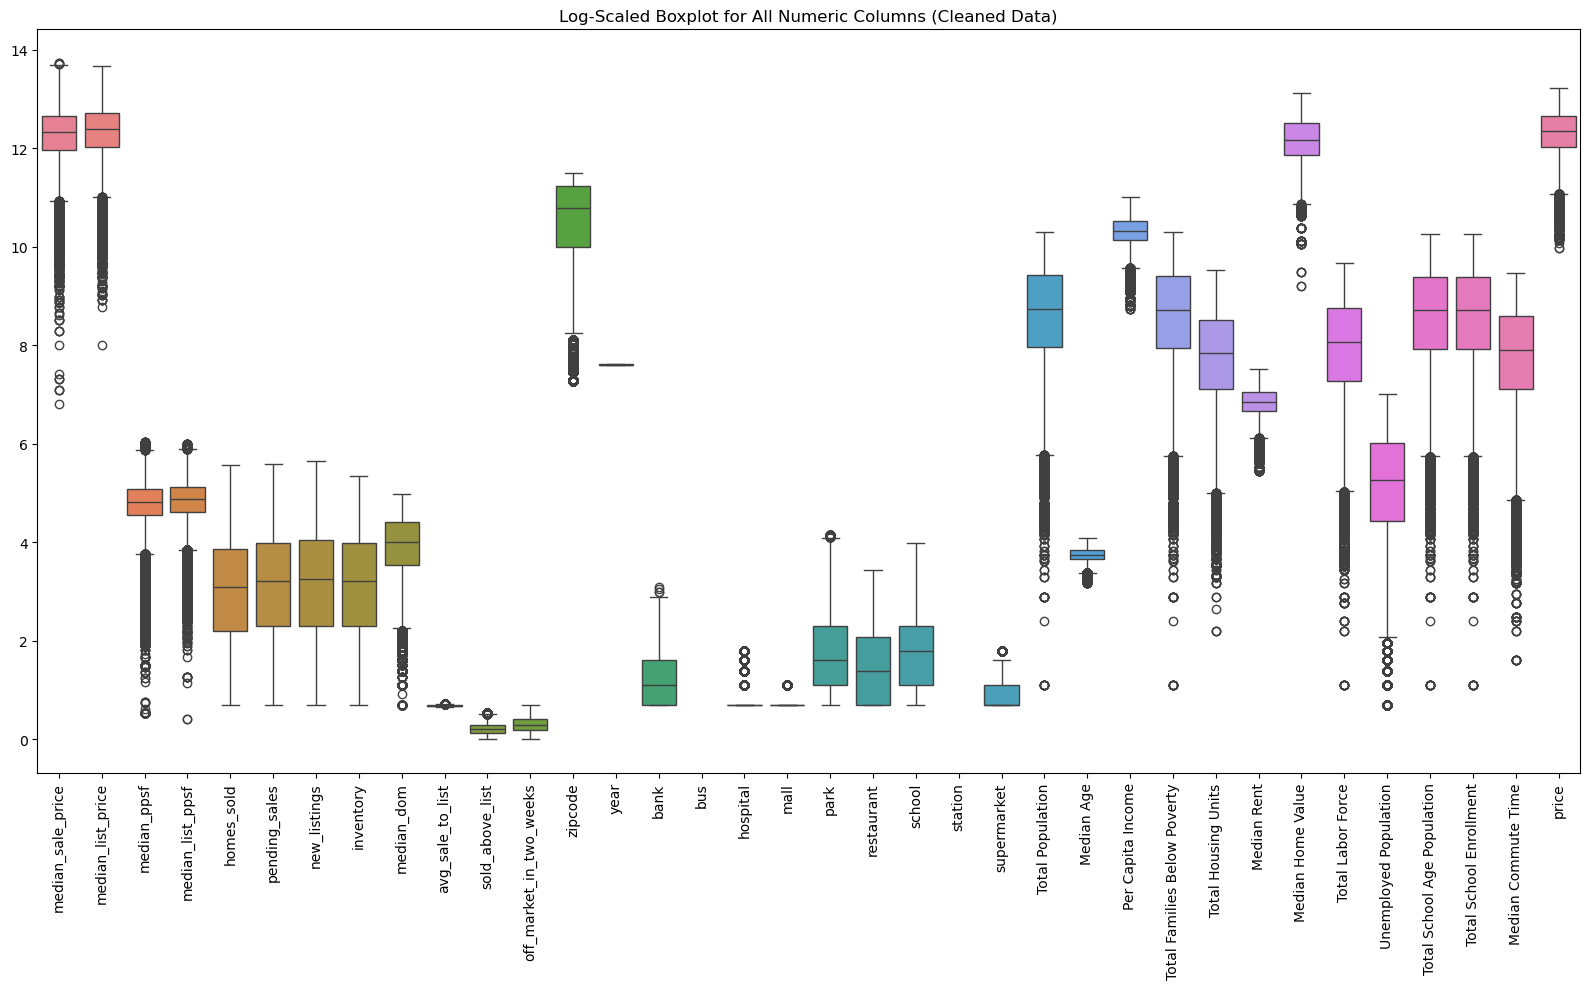

In [48]:
df_box = df_cleaned.select_dtypes(include='number').copy()
df_box[df_box <= 0] = np.nan
df_log = np.log1p(df_box)
plt.figure(figsize=(16, 10))
sns.boxplot(data=df_log, orient='v')
plt.xticks(rotation=90)
plt.title("Log-Scaled Boxplot for All Numeric Columns (Cleaned Data)")
plt.tight_layout()
plt.show()

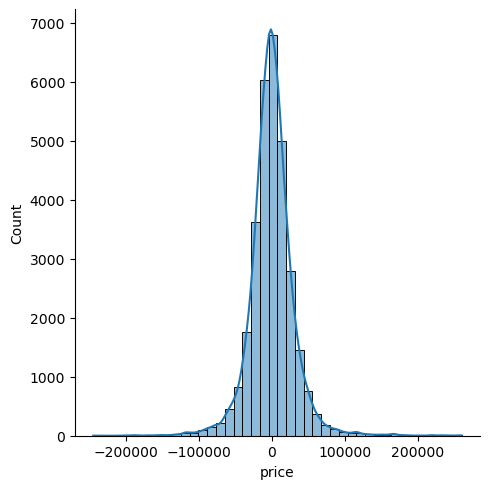

In [49]:
sns.displot(residuals,bins=42,kde=True)

 Evaluation - Linear Regression with Log
R² Score: 0.8282
MAE: 28349.71
RMSE: 43281.66


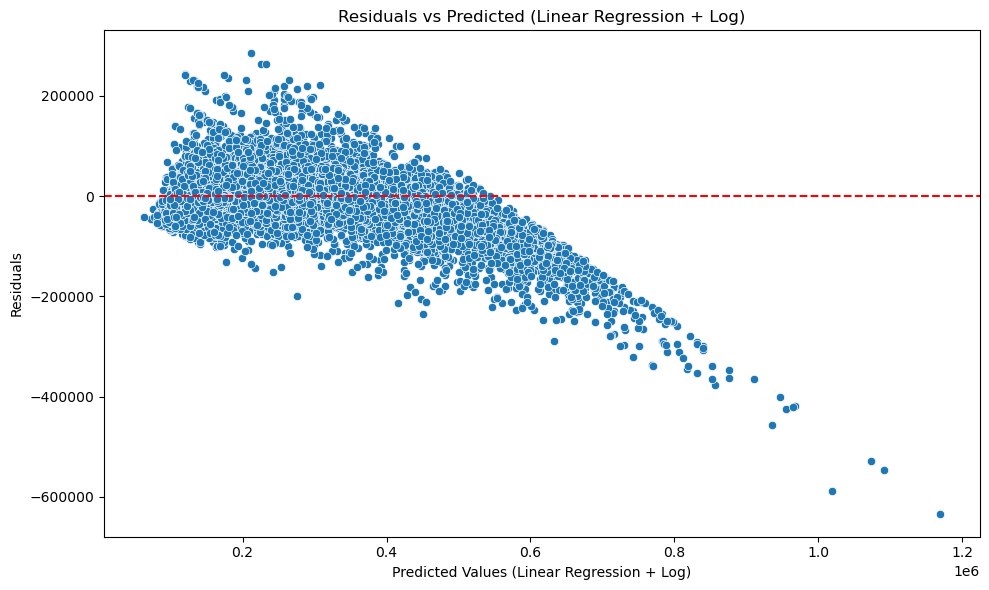

In [50]:
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']
valid_indices = y[y > 0].index
X = X.loc[valid_indices]
y = y.loc[valid_indices]
y_log = np.log(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test = np.exp(y_test_log)
residuals = y_test - y_pred
print(" Evaluation - Linear Regression with Log")
print("R² Score:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values (Linear Regression + Log)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (Linear Regression + Log)')
plt.tight_layout()
plt.show()

Evaluation - Gradient Boosting
R² Score: 0.9569
MAE: 15565.74
RMSE: 21686.22


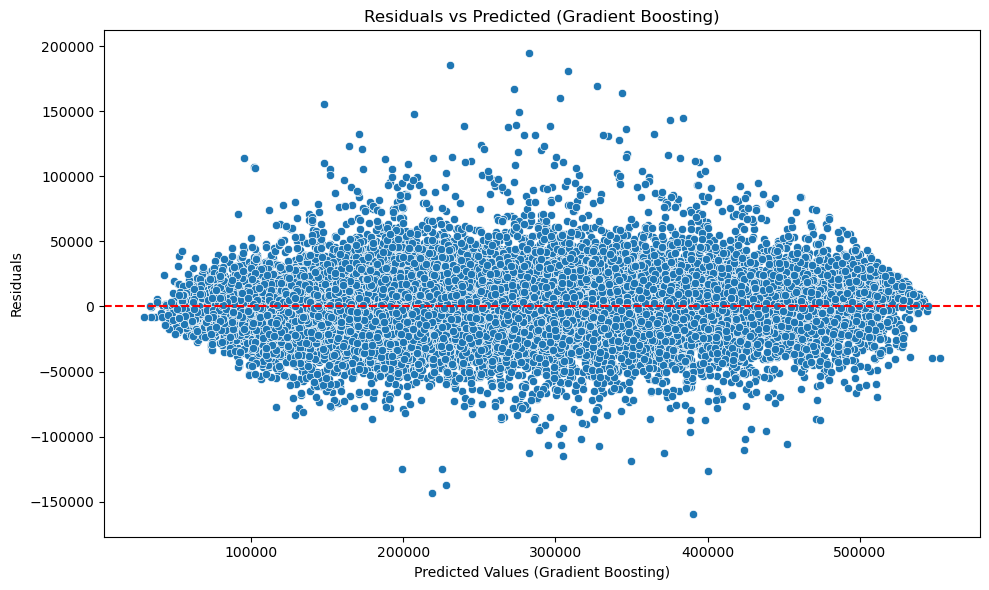

In [51]:
from sklearn.ensemble import GradientBoostingRegressor
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
residuals = y_test - y_pred
print("Evaluation - Gradient Boosting")
print("R² Score:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values (Gradient Boosting)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (Gradient Boosting)')
plt.tight_layout()
plt.show()

 RMSE: 22,696.78
 R² Score: 0.9528


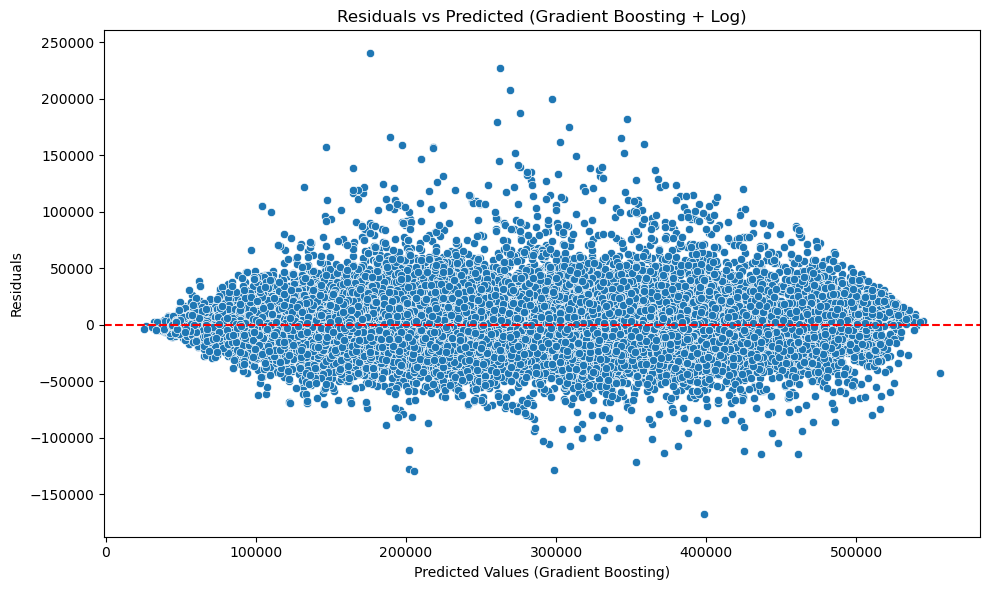

 R² Score: 0.9528


In [52]:

X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']
valid_indices = y[y > 0].index
X = X.loc[valid_indices]
y = y.loc[valid_indices]
y_log = np.log(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test = np.exp(y_test_log)
residuals = y_test - y_pred
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f" RMSE: {rmse:,.2f}")
print(f" R² Score: {r2:.4f}")
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values (Gradient Boosting)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (Gradient Boosting + Log)')
plt.tight_layout()
plt.show()
print(f" R² Score: {r2:.4f}")

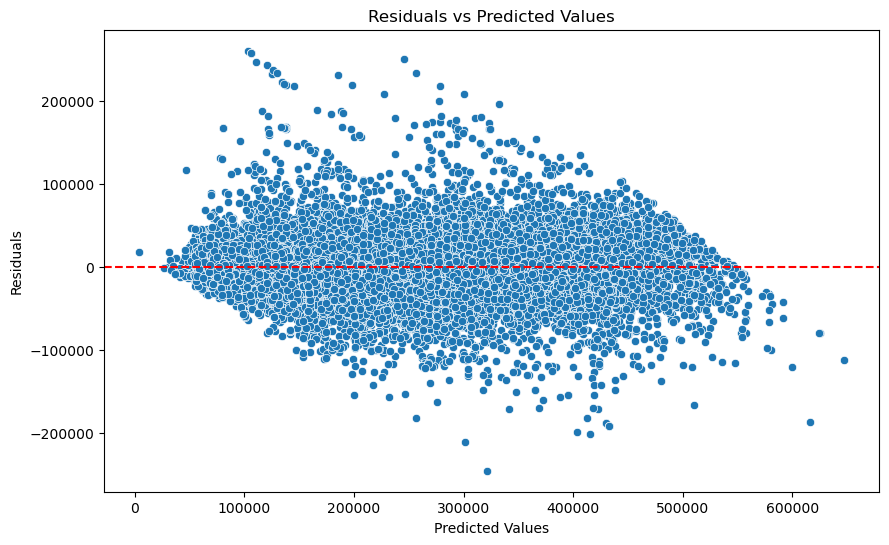

In [55]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred 
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()